In [ ]:
# Install required packages
!pip install -q kaggle tensorflow matplotlib scikit-learn

import tensorflow as tf
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from pathlib import Path

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow version: 2.19.0
✅ GPU available: True


In [ ]:
import json
import os

kaggle_credentials = {
    "username": "<username>",   # replace this
    "key": "<apikey>"
}

# Create the kaggle.json file
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ kaggle.json created successfully!")

# Test it works
!kaggle datasets list --max-size 1

✅ kaggle.json created successfully!
ref                                                        title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
jonathanpilafas/2024-march-madness-statistical-analysis    March Madness Historical DataSet (2002 to 2026)         7464927  2026-03-19 15:57:12.847000           5855         73                1  
samithsachidanandan/german-power-consumption               German Power Consumption                               57700326  2026-03-19 23:31:55.503000             47          7                1  
mczielinski/bitcoin-historical-data                        Bitcoin Historical Data                               105666242  2026-03-20 00:12:38.493000         277588       4011    

In [ ]:
# Download PlantVillage dataset
print(' Downloading PlantVillage dataset (~1.5GB)...')
!kaggle datasets download -d arjuntejaswi/plant-village -p /content/plantvillage --unzip -q
print(' PlantVillage downloaded!')

⬇️ Downloading PlantVillage dataset (~1.5GB)...
Dataset URL: https://www.kaggle.com/datasets/arjuntejaswi/plant-village
License(s): unknown
✅ PlantVillage downloaded!


In [ ]:
print('Cloning PlantDoc dataset from GitHub...')
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc -q
print(' PlantDoc downloaded!')

# Preview what's inside
print('\n📁 PlantDoc train folders:')
plantdoc_train = Path('/content/plantdoc/train')
for folder in sorted(plantdoc_train.iterdir()):
    count = len(list(folder.glob('*')))
    print(f'   {folder.name}: {count} images')

⬇️  Cloning PlantDoc dataset from GitHub...
✅ PlantDoc downloaded!

📁 PlantDoc train folders:
   Apple Scab Leaf: 83 images
   Apple leaf: 82 images
   Apple rust leaf: 79 images
   Bell_pepper leaf: 53 images
   Bell_pepper leaf spot: 62 images
   Blueberry leaf: 106 images
   Cherry leaf: 47 images
   Corn Gray leaf spot: 64 images
   Corn leaf blight: 180 images
   Corn rust leaf: 106 images
   Peach leaf: 103 images
   Potato leaf early blight: 109 images
   Potato leaf late blight: 97 images
   Raspberry leaf: 112 images
   Soyabean leaf: 57 images
   Squash Powdery mildew leaf: 124 images
   Strawberry leaf: 88 images
   Tomato Early blight leaf: 79 images
   Tomato Septoria leaf spot: 140 images
   Tomato leaf: 55 images
   Tomato leaf bacterial spot: 101 images
   Tomato leaf late blight: 101 images
   Tomato leaf mosaic virus: 44 images
   Tomato leaf yellow virus: 70 images
   Tomato mold leaf: 85 images
   Tomato two spotted spider mites leaf: 2 images
   grape leaf: 57 imag

## Cell 4 — Filter & Combine Datasets (Tomato + Potato Only)

In [ ]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

COMBINED_DIR = Path('/content/combined_dataset')
if COMBINED_DIR.exists():
    shutil.rmtree(COMBINED_DIR)

PLANTVILLAGE_MAP = {
    'Tomato_healthy':                                      'Tomato_Healthy',
    'Tomato_Early_blight':                                 'Tomato_Early_Blight',
    'Tomato_Late_blight':                                  'Tomato_Late_Blight',
    'Tomato_Septoria_leaf_spot':                           'Tomato_Septoria_Leaf_Spot',
    'Tomato_Leaf_Mold':                                    'Tomato_Leaf_Mold',
    'Tomato_Spider_mites_Two-spotted_spider_mite':         'Tomato_Spider_Mites',
    'Tomato_Target_Spot':                                  'Tomato_Target_Spot',
    'Tomato_Tomato_mosaic_virus':                          'Tomato_Mosaic_Virus',
    'Tomato_Tomato_Yellow_Leaf_Curl_Virus':                'Tomato_Yellow_Leaf_Curl',
    'Tomato_Bacterial_spot':                               'Tomato_Bacterial_Spot',
    'Potato___healthy':                                    'Potato_Healthy',
    'Potato___Early_blight':                               'Potato_Early_Blight',
    'Potato___Late_blight':                                'Potato_Late_Blight',
}

PLANTDOC_MAP = {
    'Tomato Healthy':                'Tomato_Healthy',
    'Tomato Early blight':           'Tomato_Early_Blight',
    'Tomato Late blight':            'Tomato_Late_Blight',
    'Tomato Septoria leaf spot':     'Tomato_Septoria_Leaf_Spot',
    'Tomato Leaf Mold':              'Tomato_Leaf_Mold',
    'Tomato Spider mites':           'Tomato_Spider_Mites',
    'Tomato Target Spot':            'Tomato_Target_Spot',
    'Tomato mosaic virus':           'Tomato_Mosaic_Virus',
    'Tomato Yellow Leaf Curl Virus': 'Tomato_Yellow_Leaf_Curl',
    'Tomato Bacterial spot':         'Tomato_Bacterial_Spot',
    'Potato Healthy':                'Potato_Healthy',
    'Potato Early blight':           'Potato_Early_Blight',
    'Potato Late blight':            'Potato_Late_Blight',
}

def copy_images(src_dir, class_mapping, split='train'):
    copied, skipped = 0, []
    src_path = Path(src_dir)
    if not src_path.exists():
        print(f'  Not found: {src_path}')
        return 0
    for folder in src_path.iterdir():
        if not folder.is_dir():
            continue
        unified = class_mapping.get(folder.name)
        if not unified:
            skipped.append(folder.name)
            continue
        dest = COMBINED_DIR / split / unified
        dest.mkdir(parents=True, exist_ok=True)
        for img in folder.glob('*'):
            if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                dest_name = f'{src_path.parent.name}_{img.name}'
                shutil.copy2(img, dest / dest_name)
                copied += 1
    print(f'  Skipped {len(skipped)} non-tomato/potato folders')
    return copied

print(' Copying PlantVillage...')
pv_copied = copy_images('/content/plantvillage/PlantVillage', PLANTVILLAGE_MAP, 'train')
print(f' {pv_copied} images copied')
print('\n Copying PlantDoc train...')
pd_train = copy_images('/content/plantdoc/train', PLANTDOC_MAP, 'train')
print(f'  {pd_train} images copied')

print('\nCopying PlantDoc test → val...')
pd_val = copy_images('/content/plantdoc/test', PLANTDOC_MAP, 'val')
print(f'  {pd_val} images copied')

train_count = sum(len(list(c.glob('*'))) for c in (COMBINED_DIR/'train').iterdir())
val_count   = sum(len(list(c.glob('*'))) for c in (COMBINED_DIR/'val').iterdir()) if (COMBINED_DIR/'val').exists() else 0

if val_count < train_count * 0.1:
    print('\n⚠️  Val too small — splitting 20% from train...')
    for cls_folder in (COMBINED_DIR/'train').iterdir():
        images = list(cls_folder.glob('*'))
        if len(images) < 5: continue
        _, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
        val_cls = COMBINED_DIR / 'val' / cls_folder.name
        val_cls.mkdir(parents=True, exist_ok=True)
        for img in val_imgs:
            shutil.move(str(img), val_cls / img.name)
    print('  ✅ Val split done!')

print('\n📊 Final dataset summary:')
for split in ['train', 'val']:
    split_path = COMBINED_DIR / split
    print(f'\n  [{split}]')
    total = 0
    for cls in sorted(split_path.iterdir()):
        count = len(list(cls.glob('*')))
        total += count
        print(f'    {cls.name}: {count}')
    print(f'    TOTAL: {total}')

📁 Copying PlantVillage...
  Skipped 6 non-tomato/potato folders
  ✅ 11502 images copied

📁 Copying PlantDoc train...
  Skipped 27 non-tomato/potato folders
  ✅ 140 images copied

📁 Copying PlantDoc test → val...
  Skipped 26 non-tomato/potato folders
  ✅ 11 images copied

⚠️  Val too small — splitting 20% from train...
  ✅ Val split done!

📊 Final dataset summary:

  [train]
    Potato_Early_Blight: 800
    Potato_Healthy: 121
    Potato_Late_Blight: 800
    Tomato_Bacterial_Spot: 1701
    Tomato_Early_Blight: 800
    Tomato_Healthy: 1272
    Tomato_Late_Blight: 1527
    Tomato_Leaf_Mold: 761
    Tomato_Septoria_Leaf_Spot: 1528
    TOTAL: 9310

  [val]
    Potato_Early_Blight: 200
    Potato_Healthy: 31
    Potato_Late_Blight: 200
    Tomato_Bacterial_Spot: 426
    Tomato_Early_Blight: 200
    Tomato_Healthy: 319
    Tomato_Late_Blight: 382
    Tomato_Leaf_Mold: 191
    Tomato_Septoria_Leaf_Spot: 394
    TOTAL: 2343


In [ ]:
COMBINED_DIR = Path('/content/combined_dataset')

def copy_images(src_dir, class_mapping, split='train'):
    """Copy images from source into unified folder structure."""
    copied = 0
    skipped_folders = []

    src_path = Path(src_dir)
    if not src_path.exists():
        print(f'     Path not found: {src_path}')
        return 0

    for folder in src_path.iterdir():
        if not folder.is_dir():
            continue

        unified_name = class_mapping.get(folder.name)
        if unified_name is None:
            skipped_folders.append(folder.name)
            continue

        dest = COMBINED_DIR / split / unified_name
        dest.mkdir(parents=True, exist_ok=True)

        for img in folder.glob('*'):
            if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                # Add source prefix to avoid filename collisions
                dest_name = f'{src_path.parent.name}_{img.name}'
                shutil.copy2(img, dest / dest_name)
                copied += 1

    if skipped_folders:
        print(f'   ℹ️  Skipped (not tomato/potato): {len(skipped_folders)} folders')
    return copied


if COMBINED_DIR.exists():
    shutil.rmtree(COMBINED_DIR)

print('📁 Copying PlantVillage images...')

pv_root = Path('/content/plantvillage')
pv_train_candidates = list(pv_root.rglob('train')) + [pv_root]

pv_train_dir = None
for candidate in pv_train_candidates:
    subdirs = [d for d in candidate.iterdir() if d.is_dir()] if candidate.exists() else []
    if any('Tomato' in d.name or 'Potato' in d.name for d in subdirs):
        pv_train_dir = candidate
        break

if pv_train_dir:
    print(f'   Found PlantVillage data at: {pv_train_dir}')
    pv_copied = copy_images(pv_train_dir, PLANTVILLAGE_MAP, split='train')
    print(f'    Copied {pv_copied} PlantVillage images')
else:
    print('     Could not auto-detect PlantVillage folder. Check /content/plantvillage structure.')
    pv_copied = 0

print('\n Copying PlantDoc images...')
pd_train_copied = copy_images('/content/plantdoc/train', PLANTDOC_MAP, split='train')
pd_test_copied  = copy_images('/content/plantdoc/test',  PLANTDOC_MAP, split='val')
print(f'    Copied {pd_train_copied} PlantDoc train images')
print(f'    Copied {pd_test_copied} PlantDoc val images')

print('\n Final combined dataset summary:')
total = 0
for split in ['train', 'val']:
    split_path = COMBINED_DIR / split
    if split_path.exists():
        print(f'\n  [{split}]')
        for cls in sorted(split_path.iterdir()):
            count = len(list(cls.glob('*')))
            total += count
            print(f'    {cls.name}: {count} images')
print(f'\n  TOTAL: {total} images')

📁 Copying PlantVillage images...
   ⚠️  Could not auto-detect PlantVillage folder. Check /content/plantvillage structure.

📁 Copying PlantDoc images...
   ℹ️  Skipped (not tomato/potato): 27 folders
   ℹ️  Skipped (not tomato/potato): 26 folders
   ✅ Copied 140 PlantDoc train images
   ✅ Copied 11 PlantDoc val images

📊 Final combined dataset summary:

  [train]
    Tomato_Septoria_Leaf_Spot: 140 images

  [val]
    Tomato_Septoria_Leaf_Spot: 11 images

  TOTAL: 151 images


## Cell 5 — Auto-Split Train/Val (if PlantDoc test folder was empty)

In [ ]:
from sklearn.model_selection import train_test_split

# Check if val set is too small (< 5% of train) — if so, split from train
train_path = COMBINED_DIR / 'train'
val_path   = COMBINED_DIR / 'val'

train_count = sum(len(list(c.glob('*'))) for c in train_path.iterdir() if c.is_dir())
val_count   = sum(len(list(c.glob('*'))) for c in val_path.iterdir()   if c.is_dir()) if val_path.exists() else 0

if val_count < train_count * 0.05:
    print(f'⚠️  Val set too small ({val_count} images). Auto-splitting 20% from train...')
    for cls_folder in train_path.iterdir():
        if not cls_folder.is_dir():
            continue
        images = list(cls_folder.glob('*'))
        if len(images) < 5:
            continue
        _, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
        val_cls = val_path / cls_folder.name
        val_cls.mkdir(parents=True, exist_ok=True)
        for img in val_imgs:
            shutil.move(str(img), val_cls / img.name)
    print(' Val split done!')
else:
    print(f' Val set OK ({val_count} images — {val_count*100//(train_count+val_count)}% of total)')

✅ Val set OK (11 images — 7% of total)


## Cell 6 — Load & Augment Data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 224   # MobileNetV2 native input size
BATCH_SIZE = 32

# Training: heavy augmentation to simulate Indian farm conditions
# (blur, rotation, brightness changes — mimics phone camera variability)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30.0,  # simulates varying lighting
    fill_mode='nearest'
)

# Validation: no augmentation, just normalize
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    COMBINED_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    COMBINED_DIR / 'val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f' Training samples  : {train_gen.samples}')
print(f' Validation samples: {val_gen.samples}')
print(f' Number of classes : {NUM_CLASSES}')
print(f'\n Classes detected:')
for i, name in enumerate(CLASS_NAMES):
    print(f'   [{i:2d}] {name}')

# Save class names — needed on Raspberry Pi for label display
import json
with open('/content/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print('\n class_names.json saved')

Found 9310 images belonging to 9 classes.
Found 2343 images belonging to 9 classes.
✅ Training samples  : 9310
✅ Validation samples: 2343
✅ Number of classes : 9

📋 Classes detected:
   [ 0] Potato_Early_Blight
   [ 1] Potato_Healthy
   [ 2] Potato_Late_Blight
   [ 3] Tomato_Bacterial_Spot
   [ 4] Tomato_Early_Blight
   [ 5] Tomato_Healthy
   [ 6] Tomato_Late_Blight
   [ 7] Tomato_Leaf_Mold
   [ 8] Tomato_Septoria_Leaf_Spot

✅ class_names.json saved


## Cell 7 — Build Model (MobileNetV2 + Transfer Learning)

**Strategy:**
- Phase 1: Freeze MobileNetV2 backbone → train only new top layers (5 epochs, fast)
- Phase 2: Unfreeze top 30 layers → fine-tune entire model (10 epochs, better accuracy)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,     # Remove ImageNet classification head
    weights='imagenet'     # Use ImageNet pretrained weights
)

# Phase 1: Freeze the entire base model
base_model.trainable = False

# Add custom classification head
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)              # Prevents overfitting on small dataset
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(' Model built!')
print(f'   Base model params (frozen): {base_model.count_params():,}')
print(f'   Total trainable params    : {sum([tf.size(v).numpy() for v in model.trainable_variables]):,}')
model.summary()

✅ Model built!
   Base model params (frozen): 2,257,984
   Total trainable params    : 332,809


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,353 (9.89 MB)

 Trainable params: 332,809 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Cell 8 — Phase 1 Training (Frozen Base, Train Top Layers Only)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks_phase1 = [
    ModelCheckpoint(
        '/content/best_model_phase1.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )
]

print(' Phase 1: Training top layers only (base frozen)...')
history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f'\nPhase 1 done!')
print(f'   Best val accuracy: {max(history1.history["val_accuracy"]):.2%}')

🚀 Phase 1: Training top layers only (base frozen)...
Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.6626 - loss: 1.1103
Epoch 1: val_accuracy improved from None to 0.88988, saving model to /content/best_model_phase1.h5



Epoch 1: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 171s 553ms/step - accuracy: 0.7513 - loss: 0.7854 - val_accuracy: 0.8899 - val_loss: 0.3268
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8358 - loss: 0.5145
Epoch 2: val_accuracy improved from 0.88988 to 0.90184, saving model to /content/best_model_phase1.h5



Epoch 2: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 132s 453ms/step - accuracy: 0.8380 - loss: 0.4910 - val_accuracy: 0.9018 - val_loss: 0.2930
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8437 - loss: 0.4466
Epoch 3: val_accuracy improved from 0.90184 to 0.91507, saving model to /content/best_model_phase1.h5



Epoch 3: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 132s 455ms/step - accuracy: 0.8466 - loss: 0.4429 - val_accuracy: 0.9151 - val_loss: 0.2475
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8597 - loss: 0.4065
Epoch 4: val_accuracy did not improve from 0.91507
291/291 ━━━━━━━━━━━━━━━━━━━━ 133s 458ms/step - accuracy: 0.8638 - loss: 0.3928 - val_accuracy: 0.9095 - val_loss: 0.2590
Epoch 5/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8681 - loss: 0.3692
Epoch 5: val_accuracy improved from 0.91507 to 0.92659, saving model to /content/best_model_phase1.h5



Epoch 5: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 466ms/step - accuracy: 0.8682 - loss: 0.3740 - val_accuracy: 0.9266 - val_loss: 0.2286
Epoch 6/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8933 - loss: 0.3024
Epoch 6: val_accuracy did not improve from 0.92659
291/291 ━━━━━━━━━━━━━━━━━━━━ 131s 450ms/step - accuracy: 0.8879 - loss: 0.3128 - val_accuracy: 0.9168 - val_loss: 0.2314
Epoch 7/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8938 - loss: 0.3066
Epoch 7: val_accuracy did not improve from 0.92659
291/291 ━━━━━━━━━━━━━━━━━━━━ 132s 455ms/step - accuracy: 0.8916 - loss: 0.3152 - val_accuracy: 0.9245 - val_loss: 0.2229
Epoch 8/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8954 - loss: 0.2976
Epoch 8: val_accuracy improved from 0.92659 to 0.92702, saving model to /content/best_model_phase1.h5



Epoch 8: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 133s 458ms/step - accuracy: 0.8910 - loss: 0.3048 - val_accuracy: 0.9270 - val_loss: 0.2075
Epoch 9/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8920 - loss: 0.3051
Epoch 9: val_accuracy did not improve from 0.92702
291/291 ━━━━━━━━━━━━━━━━━━━━ 132s 453ms/step - accuracy: 0.8968 - loss: 0.2968 - val_accuracy: 0.9262 - val_loss: 0.2140
Epoch 10/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9023 - loss: 0.2769
Epoch 10: val_accuracy improved from 0.92702 to 0.93598, saving model to /content/best_model_phase1.h5



Epoch 10: finished saving model to /content/best_model_phase1.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 133s 458ms/step - accuracy: 0.9003 - loss: 0.2835 - val_accuracy: 0.9360 - val_loss: 0.2017

✅ Phase 1 done!
   Best val accuracy: 93.60%


## Cell 9 — Phase 2 Training (Unfreeze Top Layers, Fine-tune)

In [ ]:
# Unfreeze top 30 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Use a much lower learning rate for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    ModelCheckpoint(
        '/content/best_model_final.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    )
]

print(' Phase 2: Fine-tuning top 30 layers...')
history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

print(f'\nPhase 2 done!')
print(f'   Best val accuracy: {max(history2.history["val_accuracy"]):.2%}')

🚀 Phase 2: Fine-tuning top 30 layers...
Epoch 1/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8196 - loss: 0.5305
Epoch 1: val_accuracy improved from None to 0.84550, saving model to /content/best_model_final.h5



Epoch 1: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 170s 525ms/step - accuracy: 0.8340 - loss: 0.4794 - val_accuracy: 0.8455 - val_loss: 0.7242 - learning_rate: 1.0000e-05
Epoch 2/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8603 - loss: 0.3989
Epoch 2: val_accuracy improved from 0.84550 to 0.86300, saving model to /content/best_model_final.h5



Epoch 2: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 464ms/step - accuracy: 0.8663 - loss: 0.3842 - val_accuracy: 0.8630 - val_loss: 0.6186 - learning_rate: 1.0000e-05
Epoch 3/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8793 - loss: 0.3463
Epoch 3: val_accuracy improved from 0.86300 to 0.87580, saving model to /content/best_model_final.h5



Epoch 3: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 463ms/step - accuracy: 0.8841 - loss: 0.3358 - val_accuracy: 0.8758 - val_loss: 0.5018 - learning_rate: 1.0000e-05
Epoch 4/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8918 - loss: 0.3207
Epoch 4: val_accuracy improved from 0.87580 to 0.89629, saving model to /content/best_model_final.h5



Epoch 4: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 463ms/step - accuracy: 0.8910 - loss: 0.3156 - val_accuracy: 0.8963 - val_loss: 0.3732 - learning_rate: 1.0000e-05
Epoch 5/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9013 - loss: 0.2839
Epoch 5: val_accuracy improved from 0.89629 to 0.91208, saving model to /content/best_model_final.h5


...


Epoch 13: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 134s 461ms/step - accuracy: 0.9317 - loss: 0.1972 - val_accuracy: 0.9513 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 14/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9325 - loss: 0.1949
Epoch 14: val_accuracy improved from 0.95134 to 0.95177, saving model to /content/best_model_final.h5



Epoch 14: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 134s 459ms/step - accuracy: 0.9353 - loss: 0.1854 - val_accuracy: 0.9518 - val_loss: 0.1505 - learning_rate: 1.0000e-05
Epoch 15/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9414 - loss: 0.1741
Epoch 15: val_accuracy improved from 0.95177 to 0.95561, saving model to /content/best_model_final.h5



Epoch 15: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 465ms/step - accuracy: 0.9411 - loss: 0.1697 - val_accuracy: 0.9556 - val_loss: 0.1427 - learning_rate: 1.0000e-05
Epoch 16/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9429 - loss: 0.1711
Epoch 16: val_accuracy improved from 0.95561 to 0.95732, saving model to /content/best_model_final.h5



Epoch 16: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 462ms/step - accuracy: 0.9406 - loss: 0.1718 - val_accuracy: 0.9573 - val_loss: 0.1387 - learning_rate: 1.0000e-05
Epoch 17/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9443 - loss: 0.1574
Epoch 17: val_accuracy did not improve from 0.95732
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 463ms/step - accuracy: 0.9435 - loss: 0.1611 - val_accuracy: 0.9548 - val_loss: 0.1448 - learning_rate: 1.0000e-05
Epoch 18/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9506 - loss: 0.1473
Epoch 18: val_accuracy did not improve from 0.95732
291/291 ━━━━━━━━━━━━━━━━━━━━ 135s 461ms/step - accuracy: 0.9510 - loss: 0.1492 - val_accuracy: 0.9552 - val_loss: 0.1373 - learning_rate: 1.0000e-05
Epoch 19/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9463 - loss: 0.1493
Epoch 19: val_accuracy did not improve from 0.95732
291/291 ━━━━━━━━━━━━━━━━━━━━ 136s 466ms/step - accuracy: 0.9476 -


Epoch 20: finished saving model to /content/best_model_final.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 134s 460ms/step - accuracy: 0.9502 - loss: 0.1420 - val_accuracy: 0.9603 - val_loss: 0.1298 - learning_rate: 1.0000e-05

✅ Phase 2 done!
   Best val accuracy: 96.03%


## Cell 10 — Plot Training Results

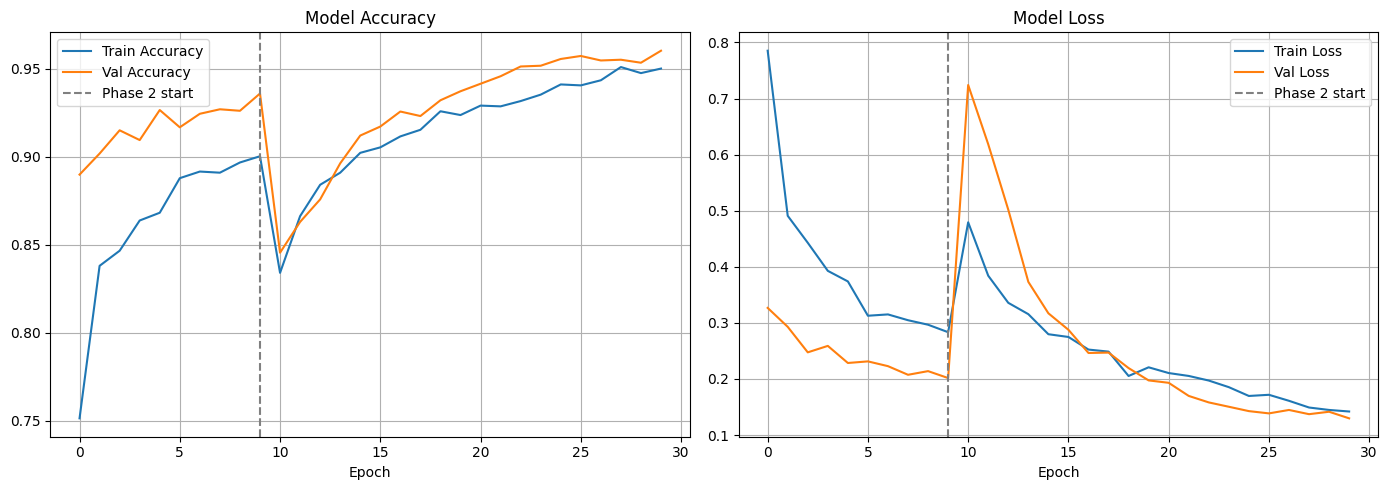

✅ Training curves saved.


In [ ]:
# Combine both phases for plotting
acc  = history1.history['accuracy']     + history2.history['accuracy']
val  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss']         + history2.history['loss']
vloss= history1.history['val_loss']     + history2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc,  label='Train Accuracy')
axes[0].plot(val,  label='Val Accuracy')
axes[0].axvline(x=len(history1.history['accuracy'])-1,
                color='gray', linestyle='--', label='Phase 2 start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(loss,  label='Train Loss')
axes[1].plot(vloss, label='Val Loss')
axes[1].axvline(x=len(history1.history['loss'])-1,
                color='gray', linestyle='--', label='Phase 2 start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print(' Training curves saved.')

## Cell 11 — Convert to TFLite (for Raspberry Pi)

In [ ]:
print(' Converting model to TFLite...')

# Load best saved model
model = tf.keras.models.load_model('/content/best_model_final.h5')

# Convert with INT8 quantization → smaller file, faster on Pi CPU
def representative_dataset():
    """Feed ~100 sample images so quantization can calibrate."""
    val_gen.reset()
    for i, (batch_x, _) in enumerate(val_gen):
        for img in batch_x:
            yield [np.expand_dims(img.astype(np.float32), axis=0)]
        if i >= 3:   # ~100 images (32 per batch × 3)
            break

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

TFLITE_PATH = '/content/crop_disease_model.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / 1024 / 1024
print(f' TFLite model saved!')
print(f'   File: {TFLITE_PATH}')
print(f'   Size: {size_mb:.2f} MB')
print(f'   Expected inference time on Pi 4: ~300-500ms per image')

🔄 Converting model to TFLite...


Saved artifact at '/tmp/tmpexv0nffb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  140332862524304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862526416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862526992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862524112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862521616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140333088552528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862527184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862526032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862521424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332862527568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1403328625258

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ TFLite model saved!
   File: /content/crop_disease_model.tflite
   Size: 2.91 MB
   Expected inference time on Pi 4: ~300-500ms per image


## Cell 12 — Quick Accuracy Test on Val Set

In [ ]:
# Test the TFLite model (same code that will run on Pi)
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0
total   = 0
val_gen.reset()

for batch_x, batch_y in val_gen:
    for img, label in zip(batch_x, batch_y):
        inp = np.expand_dims(img.astype(np.float32), axis=0)
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])[0]
        if np.argmax(pred) == np.argmax(label):
            correct += 1
        total += 1
    if total >= 200:   # Test on first 200 val images
        break

print(f' TFLite model accuracy on val set: {correct/total:.2%} ({correct}/{total})')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


✅ TFLite model accuracy on val set: 97.32% (218/224)


In [ ]:
from google.colab import files

print('⬇️  Downloading files for your Raspberry Pi...')
print('   Save these to a folder on your Pi (e.g., ~/crop_disease/)')
print()

files.download('/content/crop_disease_model.tflite')  # Main model
files.download('/content/class_names.json')            # Class labels
files.download('/content/training_curves.png')         # For your report/slides

print('\n✅ Download complete!')
print('\nNext step: Copy these 2 files to your Pi:')
print('   crop_disease_model.tflite')
print('   class_names.json')
print('\nThen run the Pi inference script (provided separately).')

⬇️  Downloading files for your Raspberry Pi...
   Save these to a folder on your Pi (e.g., ~/crop_disease/)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

Next step: Copy these 2 files to your Pi:
   crop_disease_model.tflite
   class_names.json

Then run the Pi inference script (provided separately).


In [ ]:
from pathlib import Path

# Check what actually ended up in the combined dataset
combined = Path('/content/combined_dataset')

for split in ['train', 'val']:
    split_path = combined / split
    print(f'\n[{split}]')
    if not split_path.exists():
        print('   Folder does not exist!')
        continue
    total = 0
    for cls in sorted(split_path.iterdir()):
        count = len(list(cls.glob('*')))
        total += count
        print(f'  {cls.name}: {count}')
    print(f'  TOTAL: {total}')


[train]
  Tomato_Septoria_Leaf_Spot: 140
  TOTAL: 140

[val]
  Tomato_Septoria_Leaf_Spot: 11
  TOTAL: 11


In [ ]:
# Check PlantVillage structure
pv = Path('/content/plantvillage')
print('PlantVillage folders found:')
for f in sorted(pv.rglob('*'))[:20]:  # First 20 items
    print(f'  {f}')

PlantVillage folders found:
  /content/plantvillage/PlantVillage
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Spot 3262.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B.Spot 9169.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/018e494e-d2eb-468b-9d02-40219d9f4921___JR_B.Spot 9045.JPG
  /content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/01940b6d-7dea-4889-a7b8-a35f4e9bba34___NREC_B.Spo

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Testing with: Tomato_Late_Blight/plantvillage_736cd652-e63d-4b01-a3c6-6859bc095fb9___GHLB_PS Leaf 39 Day 16.jpg



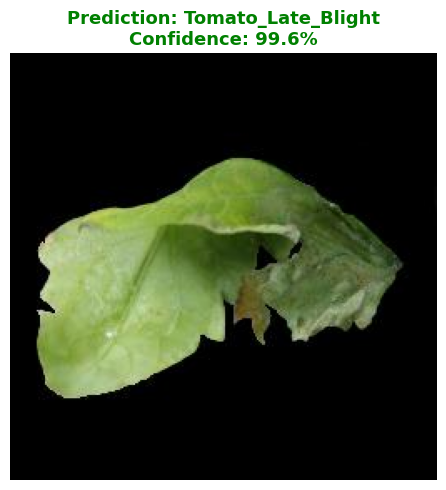

Top 3 predictions:
  1. Tomato_Late_Blight                  99.6%  █████████████████████████████
  2. Tomato_Septoria_Leaf_Spot           0.0%  
  3. Tomato_Leaf_Mold                    0.0%  


In [ ]:
import numpy as np
import tensorflow as tf
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from pathlib import Path

interpreter = tf.lite.Interpreter(model_path='/content/crop_disease_model.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

with open('/content/class_names.json') as f:
    CLASS_NAMES = json.load(f)

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    inp = np.expand_dims(img_array.astype(np.float32), axis=0)

    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    predictions = interpreter.get_tensor(output_details[0]['index'])[0]

    top3_idx = predictions.argsort()[-3:][::-1]

    plt.figure(figsize=(6, 5))
    plt.imshow(mpimg.imread(str(img_path)))
    plt.axis('off')
    plt.title(f"Prediction: {CLASS_NAMES[top3_idx[0]]}\nConfidence: {predictions[top3_idx[0]]:.1%}",
              fontsize=13, fontweight='bold', color='green')
    plt.tight_layout()
    plt.show()

    print("Top 3 predictions:")
    for i, idx in enumerate(top3_idx):
        bar = '█' * int(predictions[idx] * 30)
        print(f"  {i+1}. {CLASS_NAMES[idx]:<35} {predictions[idx]:.1%}  {bar}")

val_images = list(Path('/content/combined_dataset/val').rglob('*.jpg'))
sample = random.choice(val_images)
print(f"Testing with: {sample.parent.name}/{sample.name}\n")
predict_image(sample)